In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
df=pd.read_csv("/content/drive/MyDrive/MLproject/Student Social Media And Mental Health Impact.csv")

In [9]:
df.shape

(5000, 13)

In [10]:
df.sample(5)

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
668,22,Female,Canada,Undergraduate,YouTube,Education,4.1,156,3.9,1.3,7.2,Medium,6.3
1135,20,Female,India,Undergraduate,Instagram,Entertainment,5.4,192,3.8,2.2,5.4,High,6.0
2834,21,Male,Other,Undergraduate,Facebook,Networking,5.9,209,3.2,0.7,6.0,Very High,7.0
3314,21,Male,Mexico,Undergraduate,WhatsApp,News,6.2,192,2.2,1.0,5.9,Very High,6.0
1303,22,Male,Germany,Undergraduate,Facebook,Networking,3.3,127,3.8,2.2,8.2,Medium,8.0


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [12]:
df.duplicated().sum()

np.int64(2)

In [13]:
df = df.drop_duplicates()

In [14]:
df.shape

(4998, 13)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [17]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.750760,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.668406,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [18]:
num_col=df.select_dtypes(include=['int64','float64']).columns

In [19]:
num_col

Index(['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours',
       'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score'],
      dtype='object')

In [20]:
cat_col=df.select_dtypes(include=['object']).columns

In [21]:
cat_col

Index(['Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Stress_Level'],
      dtype='object')

Gender
Gender
Male      2634
Female    2364
Name: count, dtype: int64


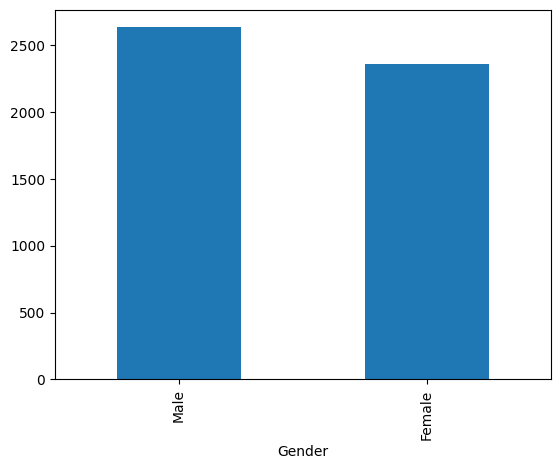


Country
Country
Other        1879
India         389
USA           354
Canada        230
Australia     198
             ... 
Armenia         1
Bosnia          1
Kuwait          1
Yemen           1
Syria           1
Name: count, Length: 111, dtype: int64


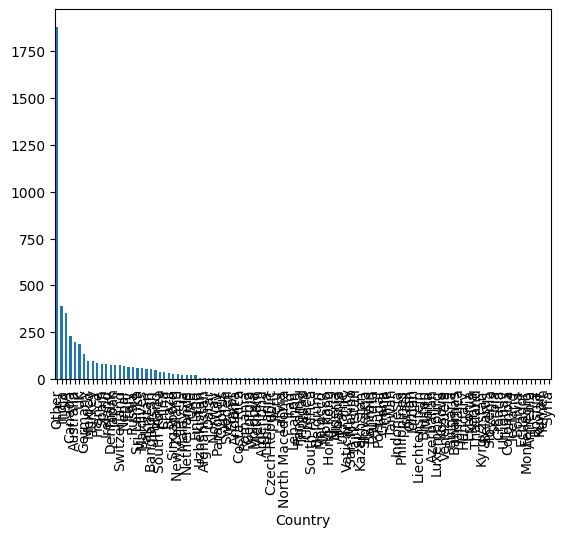


Academic_Level
Academic_Level
Undergraduate    3630
Graduate          918
High School       450
Name: count, dtype: int64


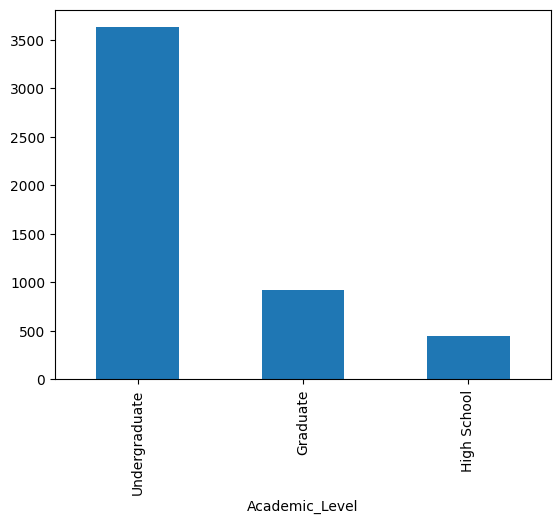


Most_Used_Platform
Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      522
YouTube       491
Twitter       462
Snapchat      419
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64


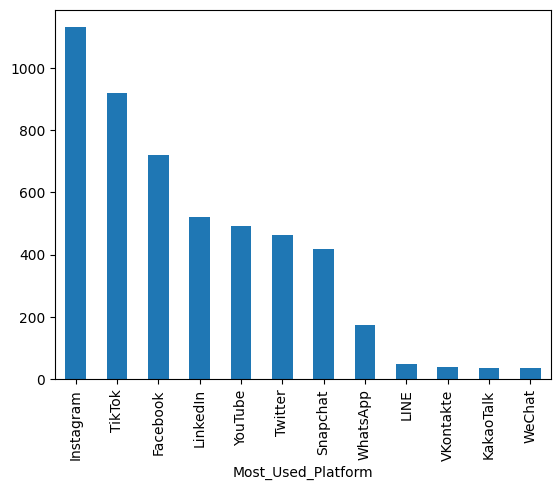


Purpose_Of_Use
Purpose_Of_Use
Entertainment    2551
Education        1093
Networking        793
News              561
Name: count, dtype: int64


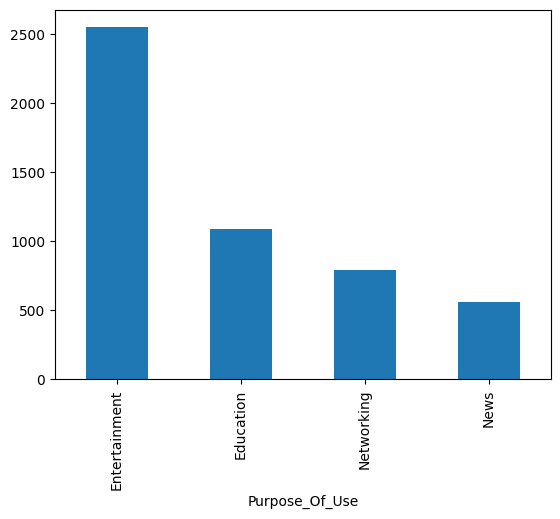


Stress_Level
Stress_Level
Very High    1621
High         1439
Medium       1295
Low           643
Name: count, dtype: int64


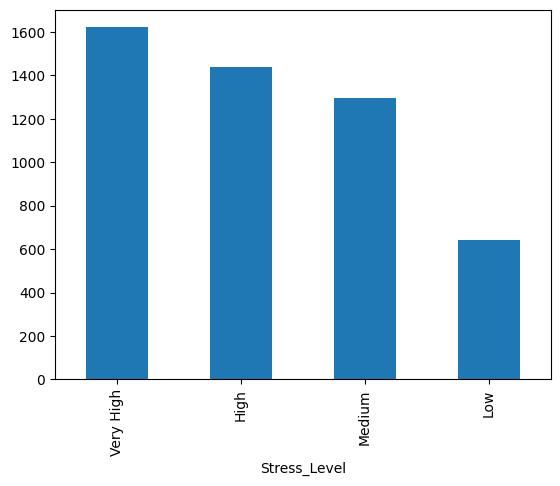

In [22]:
for i in cat_col:
  print(i)
  print(df[i].value_counts())
  df[i].value_counts().plot(kind='bar')
  plt.show()
  print()

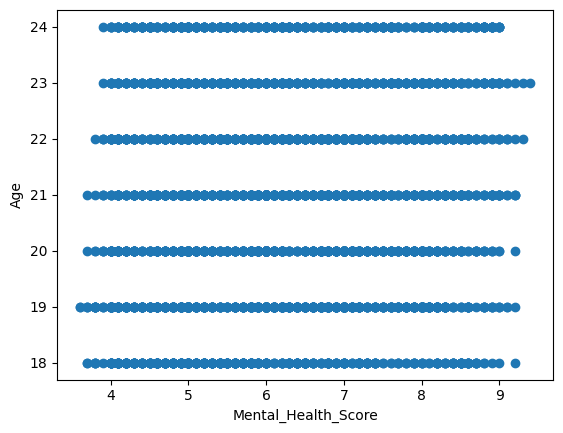

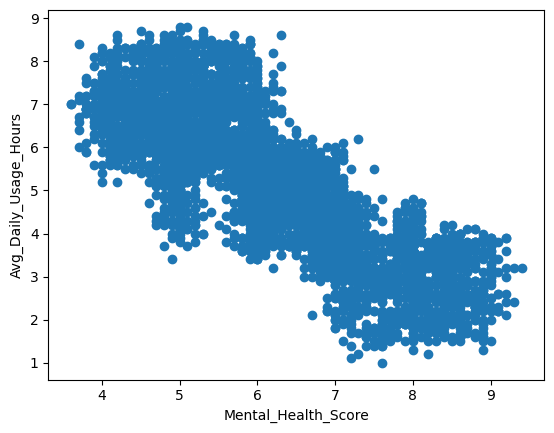

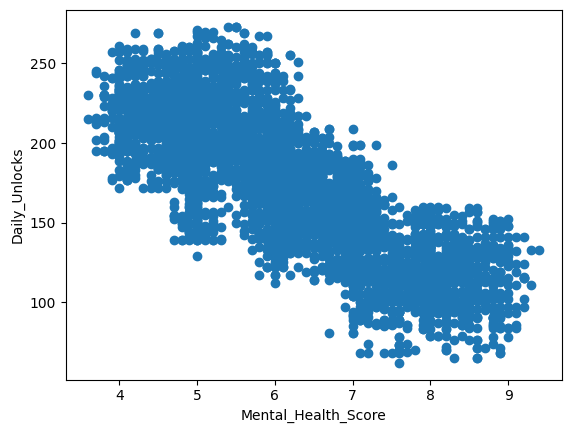

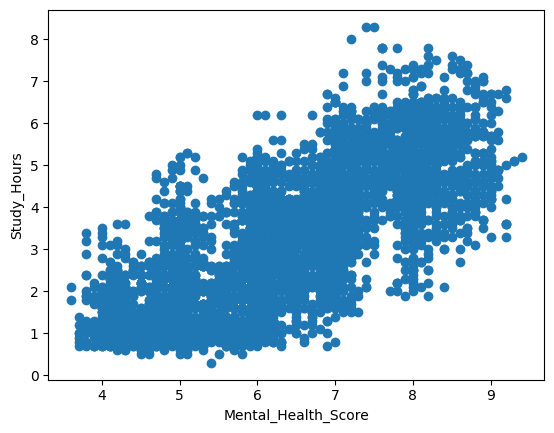

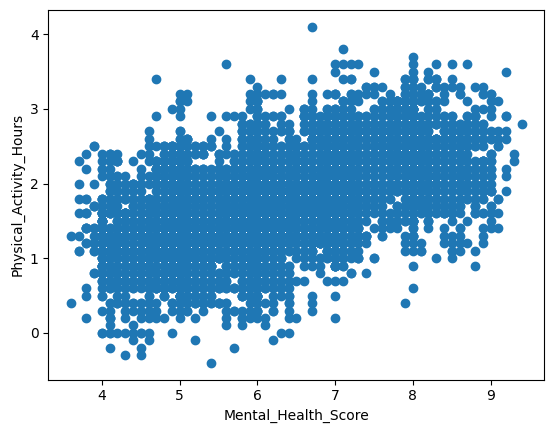

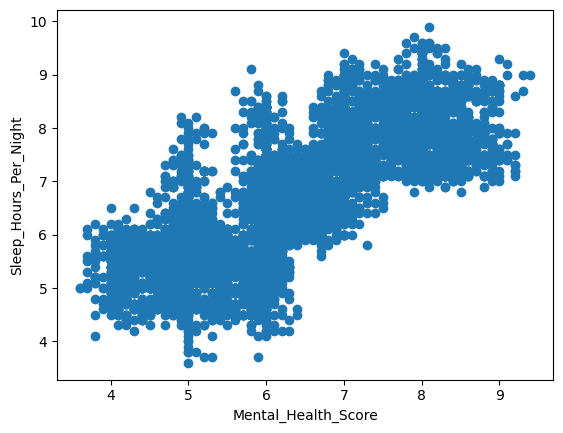

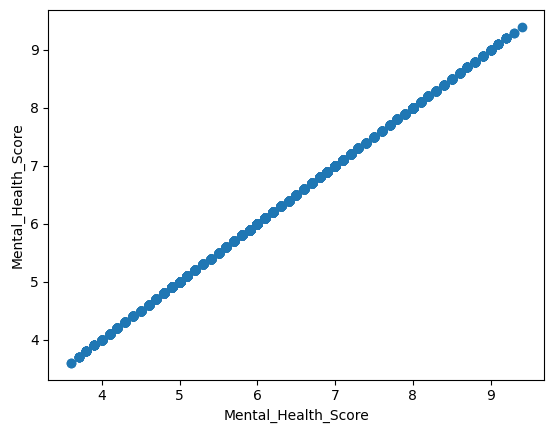

In [23]:
target=df['Mental_Health_Score']

for i in num_col:
  plt.scatter(target,df[i])
  plt.xlabel('Mental_Health_Score')
  plt.ylabel(i)
  plt.show()

In [24]:
df[num_col].skew()

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.040623
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

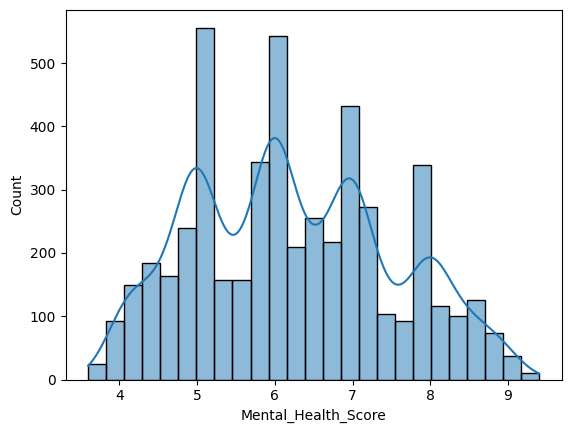

In [25]:
sns.histplot(df['Mental_Health_Score'],kde=True)

<Axes: >

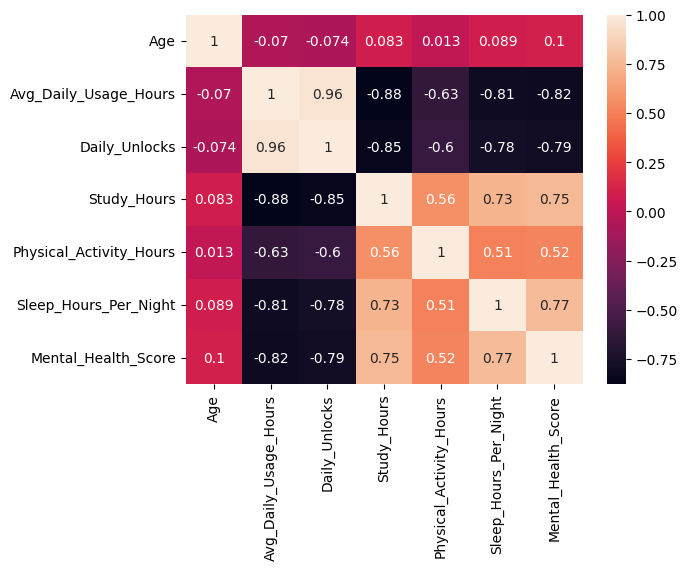

In [26]:
sns.heatmap(df[num_col].corr(),annot=True)

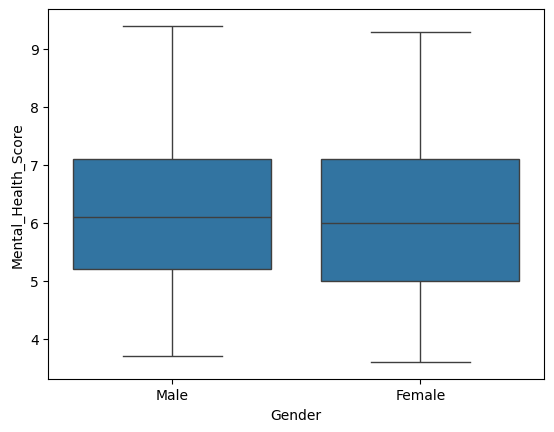

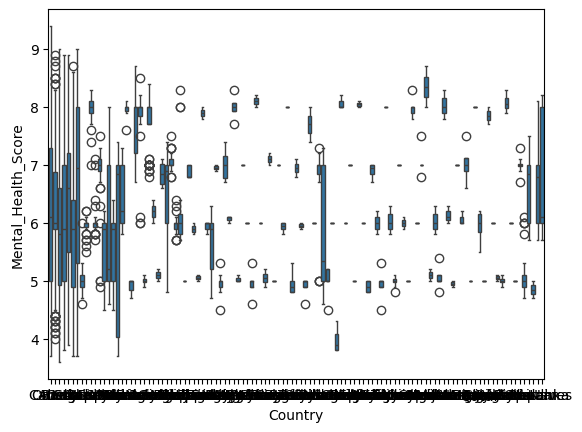

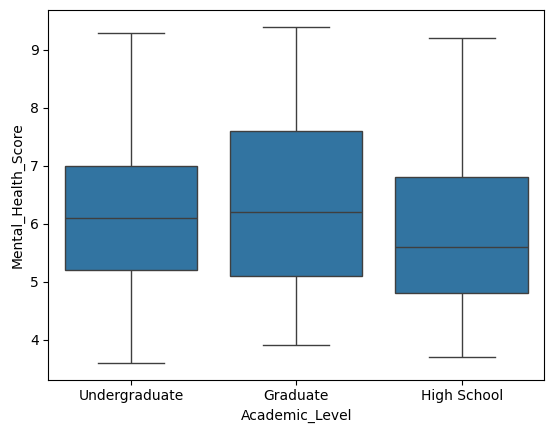

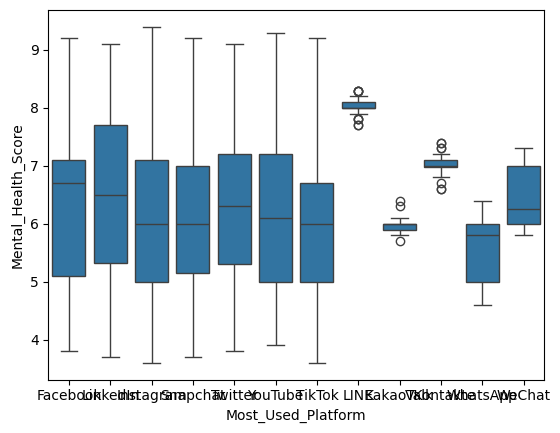

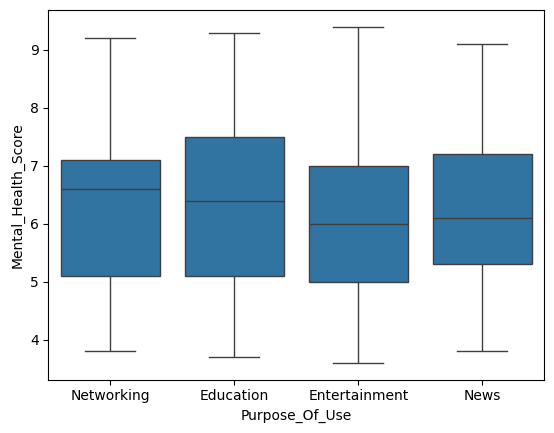

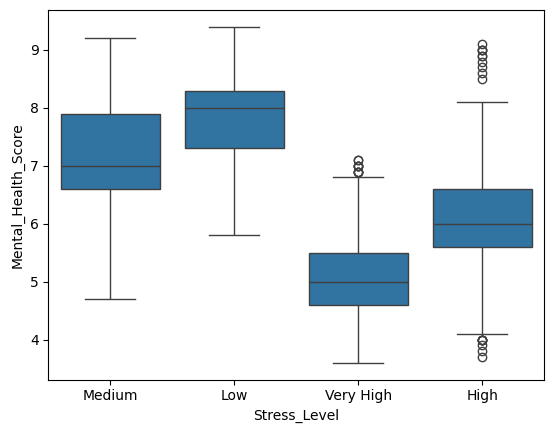

In [27]:
for i in cat_col:
  sns.boxplot(x=df[i],y=df['Mental_Health_Score'])
  plt.show()

In [28]:
num_col = df.select_dtypes(include='number')
q1 = num_col.quantile(0.25)
q3 = num_col.quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = (num_col < lower_bound) | (num_col > upper_bound)

print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


In [29]:
num_col

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
0,21,4.0,134,4.5,2.2,6.7,6.8
1,23,1.6,73,7.0,2.4,8.6,7.6
2,22,4.6,166,4.0,1.8,6.7,7.0
3,18,7.0,220,1.0,1.7,5.4,5.3
4,24,7.5,237,1.0,1.1,5.0,4.4
...,...,...,...,...,...,...,...
4995,18,1.9,89,6.1,2.2,7.9,7.9
4996,18,6.6,216,2.3,1.8,6.0,4.7
4997,19,3.8,151,5.4,1.4,7.5,7.0
4998,18,3.8,119,4.0,1.5,6.4,6.7


In [30]:
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)

In [31]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [32]:
top_country=df['Country'].value_counts().index[:10].tolist()

In [33]:
def group_country(x):
  if x in top_country:
    return x
  else:
    return 'Other'

In [34]:
df['Country']=df['Country'].apply(group_country)

In [35]:
df['Country'].value_counts()

,count
Country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


In [36]:
skew_col=['Study_Hours']
other_num_col=['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']
ordinal_col=['Stress_Level']
nominal_col=['Gender','Academic_Level','Most_Used_Platform','Purpose_Of_Use','Country']

In [37]:
feature_Col=skew_col+other_num_col+ordinal_col+nominal_col

In [38]:
x=df[feature_Col]
y=df['Mental_Health_Score']

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,FunctionTransformer
skew_pipeline=Pipeline(steps=[
    ('log_transformer',FunctionTransformer(np.log1p)),
    ('scaler',StandardScaler())
])

normal__num_pipeline=Pipeline(steps=[
    ('scaler',StandardScaler())
])
ordinal_pipeline=Pipeline(steps=[
    ('ordinal_encoder',OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))
])
nominal_pipeline=Pipeline(steps=[
    ('one_hot_encoder',OneHotEncoder(handle_unknown='ignore'))
])


In [40]:
from sklearn.compose import ColumnTransformer
preprocessor=ColumnTransformer([
    ('skew_pipeline',skew_pipeline,skew_col),
    ('normal_pipeline',normal__num_pipeline,other_num_col),
    ('ordinal_pipeline',ordinal_pipeline,ordinal_col),
    ('nominal_pipeline',nominal_pipeline,nominal_col)
])
print(preprocessor)

ColumnTransformer(transformers=[('skew_pipeline',
                                 Pipeline(steps=[('log_transformer',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['Study_Hours']),
                                ('normal_pipeline',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Age', 'Avg_Daily_Usage_Hours',
                                  'Daily_Unlocks', 'Physical_Activity_Hours',
                                  'Sleep_Hours_Per_Night']),
                                ('ordinal_pipeline',
                                 Pipeline(steps=[('ordinal_encoder',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                      

In [41]:
from sklearn import set_config

set_config(display='diagram')

preprocessor

ColumnTransformer(transformers=[('skew_pipeline',
                                 Pipeline(steps=[('log_transformer',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['Study_Hours']),
                                ('normal_pipeline',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Age', 'Avg_Daily_Usage_Hours',
                                  'Daily_Unlocks', 'Physical_Activity_Hours',
                                  'Sleep_Hours_Per_Night']),
                                ('ordinal_pipeline',
                                 Pipeline(steps=[('ordinal_encoder',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Very '
                                                                              'High']]))]),
                                 ['Stress_Level']),
                                ('nominal_pipeline',
                                 Pipeline(steps=[('one_hot_encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Academic_Level',
                                  'Most_Used_Platform', 'Purpose_Of_Use',
                                  'Country'])])

In [42]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [44]:
lr_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',LinearRegression())
])
dt_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',DecisionTreeRegressor())
])
rf_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',RandomForestRegressor())
])
svr_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',SVR())
])
knn_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',KNeighborsRegressor())
])

In [45]:
lr_pipeline.fit(x_train,y_train)
dt_pipeline.fit(x_train,y_train)
rf_pipeline.fit(x_train,y_train)
svr_pipeline.fit(x_train,y_train)
knn_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('skew_pipeline',
                                                  Pipeline(steps=[('log_transformer',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('normal_pipeline',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Daily_Unlocks',
                                                   'Physical_Activity_Hours',
                                                   'Sleep_...
                                                 ('ordinal_pipeline',
                                                  Pipeline(steps=[('ordinal_encoder',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']]))]),
                                                  ['Stress_Level']),
                                                 ('nominal_pipeline',
                                                  Pipeline(steps=[('one_hot_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Academic_Level',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use',
                                                   'Country'])])),
                ('model', KNeighborsRegressor())])

In [46]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import cross_val_score

lr_predict=lr_pipeline.predict(x_test)
dt_predict=dt_pipeline.predict(x_test)
rf_predict=rf_pipeline.predict(x_test)
svr_predict=svr_pipeline.predict(x_test)
knn_predict=knn_pipeline.predict(x_test)

In [47]:
lr_r2=r2_score(y_test,lr_predict)
dt_r2=r2_score(y_test,dt_predict)
rf_r2=r2_score(y_test,rf_predict)
svr_r2=r2_score(y_test,svr_predict)
knn_r2=r2_score(y_test,knn_predict)

print('Linear Regression R2 Score:',lr_r2)
print('Decision Tree R2 Score:',dt_r2)
print('Random Forest R2 Score:',rf_r2)
print('Support Vector Machine R2 Score:',svr_r2)
print('K-Nearest Neighbors R2 Score:',knn_r2)


Linear Regression R2 Score: 0.739794461743302
Decision Tree R2 Score: 0.7451534395988272
Random Forest R2 Score: 0.8755836400776532
Support Vector Machine R2 Score: 0.8071738284948615
K-Nearest Neighbors R2 Score: 0.840021144940093


In [48]:
lr_pred_train=lr_pipeline.predict(x_train)
dt_pred_train=dt_pipeline.predict(x_train)
rf_pred_train=rf_pipeline.predict(x_train)
svr_pred_train=svr_pipeline.predict(x_train)
knn_pred_train=knn_pipeline.predict(x_train)



In [49]:
lr_r2_train=r2_score(y_train,lr_pred_train)
dt_r2_train=r2_score(y_train,dt_pred_train)
rf_r2_train=r2_score(y_train,rf_pred_train)
svr_r2_train=r2_score(y_train,svr_pred_train)
knn_r2_train=r2_score(y_train,knn_pred_train)

print('Linear Regression R2 Score:',lr_r2_train)
print('Decision Tree R2 Score:',dt_r2_train)
print('Random Forest R2 Score:',rf_r2_train)
print('Support Vector Machine R2 Score:',svr_r2_train)
print('K-Nearest Neighbors R2 Score:',knn_r2_train)



Linear Regression R2 Score: 0.7236771199387538
Decision Tree R2 Score: 0.9999918615442751
Random Forest R2 Score: 0.9810628081645547
Support Vector Machine R2 Score: 0.826412384261447
K-Nearest Neighbors R2 Score: 0.8906004185237436


In [56]:
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

rf_random = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='r2'
)

rf_random.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('skew_pipeline',
                                                                               Pipeline(steps=[('log_transformer',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('normal_pipeline',
                                                                               Pipeline(steps=[('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unlocks'...
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['Gender',
                                                                                'Academic_Level',
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'Country'])])),
                                             ('model',
                                              RandomForestRegressor())]),
                   n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 10, 20, 30],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='r2', verbose=2)

In [60]:
rf_random.best_params_



{'model__n_estimators': 300,
 'model__min_samples_split': 2,
 'model__min_samples_leaf': 1,
 'model__max_depth': 30}

In [61]:
rf_best_pipeline = rf_random.best_estimator_

rf_best_pred = rf_best_pipeline.predict(x_test)

rf_best_r2 = r2_score(y_test, rf_best_pred)

print(rf_best_r2)

0.8788026936179878


In [62]:
import joblib
joblib.dump(rf_best_pipeline,'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']